Does a partial least squares regression predict residues of functional importance?

first load the MSA

[[20 20 20 ... 20 20 20]
 [20 20 20 ... 20 20 20]
 [20 20 20 ... 20 20 20]
 ...
 [20 20 20 ... 20 20 20]
 [20 20 20 ... 20 20 20]
 [20 20 20 ... 20 20 20]]
MSA shape: (58, 1414) (sequences x positions)
(57, 1238)


Text(0.5, 1.0, 'narG collection (pixel color = amino acid)')

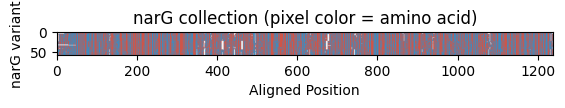

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import AlignIO

# Load MSA
msa = AlignIO.read("../out/aaseqs/K00370/complete_with_reference.aln-fasta", "fasta")

# Convert letters to numbers (0-20 for AAs + gap)
aa_to_int = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY-")}
msa_matrix = np.array([
    [aa_to_int[aa] for aa in record.seq] 
    for record in msa
])

print(msa_matrix)
hydrophobic = {'A', 'V', 'L', 'I', 'M', 'F', 'W', 'P', 'G', 'C'}
hydrophilic = {'S', 'T', 'N', 'Q', 'Y', 'D', 'E', 'K', 'R', 'H'}

aa_to_binary = {aa: 0 for aa in hydrophobic}
aa_to_binary.update({aa: 1 for aa in hydrophilic})
aa_to_binary['-'] = 0.5

msa_binary = np.array([
    [aa_to_binary[aa] for aa in record.seq] 
    for record in msa
])

print(f"MSA shape: {msa_matrix.shape} (sequences x positions)")

num_positions = len(msa_matrix[0])

num_seqs, num_positions = msa_matrix.shape

#filter columns with low coverage
gap_threshold = 0.5 * num_seqs
clean_columns = [
    col for col in range(num_positions) 
    if np.sum(msa_matrix[:, col] == aa_to_int['-']) <= gap_threshold
]
    
msa_binary = msa_binary[:, clean_columns]

msa_binary = np.delete(msa_binary, 8, axis = 0)

print(msa_binary.shape)
plt.show()
plt.imshow(msa_binary, cmap = 'RdBu',vmin = -0.3, vmax = 1.3)
plt.ylabel('narG variant')
plt.xlabel('Aligned Position')
plt.title('narG collection (pixel color = amino acid)')



compute rate parameters for each entry

In [11]:
group_membership = pd.read_csv("../out/groups/assignments_K00370_v2.tsv", sep='\t',header=None).values
groups = np.zeros(57)
for i in range(len(group_membership)):
    groups[i] = group_membership[i][0][-1]


coefficients = [-0.14, 0,         -1.26, 0,          0,         1.87,
  0.18,  0.55] #from regression

intercept = 0.71

rates = np.zeros(57)
for i in range(len(rates)):
    rates[i] = coefficients[int(groups[i] - 1)] + intercept


### run the PLS by encoding the sequences onto a smaller dimension. 

Optimal number of components: 4
Found 62 important residues:
[  68   84  101  102  126  129  139  157  194  243  273  278  285  288
  293  301  302  324  331  349  350  356  442  447  449  502  509  562
  564  608  626  636  678  682  688  689  692  741  742  758  759  761
  786  819  823  825  832  841  892  921  948  949  959  986  990 1010
 1031 1053 1144 1223 1224 1231]


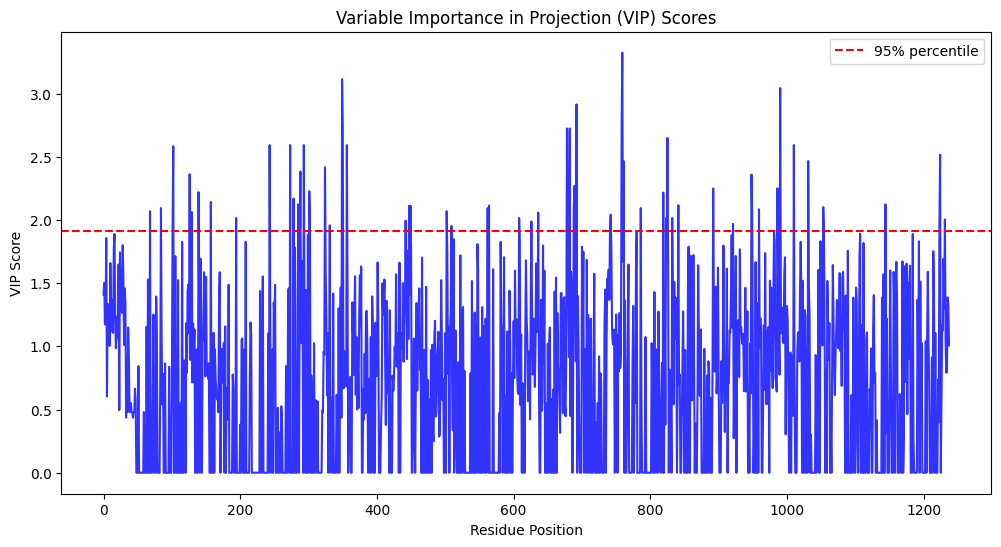

In [12]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, permutation_test_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

#
def calculate_vip(pls_model):
    """
    Calculate Variable Importance in Projection (VIP) scores
    """
    t = pls_model.x_scores_  # X scores
    w = pls_model.x_weights_  # X weights
    q = pls_model.y_loadings_  # Y loadings
    
    p = w.shape[0]
    vip = np.zeros(p)
    
    for i in range(p):
        # VIP for variable i
        vip[i] = np.sqrt(p * np.sum(w[i,:]**2 * np.sum(q**2, axis=0)) / 
                         np.sum(np.sum(q**2, axis=0)))
    
    return vip

scaler = StandardScaler()

Y = scaler.fit_transform(rates.reshape(-1, 1)).flatten() #transform data
X = scaler.fit_transform(msa_binary) 

#find the optimal number of componenets with a cross validation scheme
components_range = min(10, len(rates) - 5)
cv_scores = []

for n_comp in range(1, components_range + 1):
    pls = PLSRegression(n_components=n_comp)
    scores = cross_val_score(pls, X, Y, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

optimal_components = np.argmax(cv_scores) + 1
print(f"Optimal number of components: {optimal_components}")

#fit the model
pls_final = PLSRegression(n_components=optimal_components)
pls_final.fit(X, Y)
vip_scores = calculate_vip(pls_final)

important_cutoff = np.percentile(vip_scores, 95)  # Top 5%
important_residues = np.where(vip_scores > important_cutoff)[0]

print(f"Found {len(important_residues)} important residues:")
print(important_residues)

# Plot VIP scores
plt.figure(figsize=(12, 6))
plt.plot(vip_scores, color = 'Blue', alpha = 0.8)
plt.axhline(y=important_cutoff, color='r', linestyle='--', label='95% percentile')
plt.xlabel('Residue Position')
plt.ylabel('VIP Score')
plt.title('Variable Importance in Projection (VIP) Scores')
plt.legend()
plt.show()

## or try a bootstrapping

In [ ]:
def bootstrap_pls(X, Y, n_components=2, n_bootstraps=200, target_residues=30):
    """
    Simple bootstrapping that ensures we get close to target number of residues
    """
    # Get original VIP scores
    pls = PLSRegression(n_components=n_components)
    pls.fit(X, Y)
    vip_scores = calculate_vip(pls)
    
    # Count how often each residue appears in top residues across bootstrap samples
    bootstrap_counts = np.zeros(len(vip_scores))
    
    for i in range(n_bootstraps):
        # Bootstrap sample
        indices = np.random.choice(len(X), size=len(X), replace=True)
        X_bs, Y_bs = X[indices], Y[indices]
        
        # Fit PLS on bootstrap sample
        pls_bs = PLSRegression(n_components=n_components)
        pls_bs.fit(X_bs, Y_bs)
        vip_bs = calculate_vip(pls_bs)
        
        # Mark top target_residues in this bootstrap
        top_indices = np.argsort(vip_bs)[-target_residues:]
        bootstrap_counts[top_indices] += 1
    
    # Instead of fixed threshold, take the top target_residues by stability
    final_positions = np.argsort(bootstrap_counts)[-target_residues:]
    
    print(f"Selected {len(final_positions)} residues")
    print(f"Stability range: {bootstrap_counts[final_positions].min()}-{bootstrap_counts[final_positions].max()} bootstraps")
    
    return final_positions

# Usage:
important_residues = bootstrap_pls(X, Y, optimal_components, target_residues=30)

Selected 30 residues
Stability range: 49.0-151.0 bootstraps


In [42]:


# Get the reference sequence in MSA
ref_seq = str(msa[8].seq)

# Create mapping from filtered MSA positions back to original reference positions
# Only consider positions that survived the gap filtering
original_positions = [clean_columns[i] for i in important_residues]

print(f"Important residues in filtered MSA: {important_residues}")
print(f"Corresponding positions in original alignment: {original_positions}") #fix gap removal

# Now map these to reference sequence indices 
ref_positions = []
current_ref_idx = 0

for pos in original_positions:
    # Count how many non-gap characters in reference up to this position
    non_gap_count = 0
    for i in range(pos + 1):  # +1 because we want position inclusive
        if ref_seq[i] != '-':
            non_gap_count += 1
    
    # The reference index is the count of non-gap residues up to this point
    ref_positions.append(non_gap_count)

print(f"Positions in reference sequence (1-based): {[x for x in ref_positions]}")

# Save the positions to a simple text file
with open("../out/aaseqs/K00370/rate_residues.txt", "w") as f:
    for pos in ref_positions:
        f.write(f"{pos}\n")

print(f"Saved {len(ref_positions)} important residues to 'rate_residues.txt'")
print("Positions:", ref_positions)

# Generate the PyMOL selection command
resi_string = "+".join(map(str, ref_positions))
pymol_command = f"select important_residues, resi {resi_string}"


Important residues in filtered MSA: [ 285  442  981  126  689  819  139  907  331  301  986 1010  243  356
  273  293 1031  761  324  678  758 1224  682  825  102  350  692  759
  990  349]
Corresponding positions in original alignment: [341, 557, 1111, 181, 814, 945, 195, 1036, 390, 357, 1116, 1140, 299, 427, 329, 349, 1161, 887, 380, 803, 884, 1355, 807, 951, 157, 419, 817, 885, 1120, 418]
Positions in reference sequence (1-based): [282, 446, 981, 123, 690, 821, 136, 908, 328, 298, 986, 1010, 240, 353, 270, 290, 1031, 763, 321, 679, 760, 1223, 683, 827, 99, 347, 693, 761, 990, 346]
Saved 30 important residues to 'rate_residues.txt'
Positions: [282, 446, 981, 123, 690, 821, 136, 908, 328, 298, 986, 1010, 240, 353, 270, 290, 1031, 763, 321, 679, 760, 1223, 683, 827, 99, 347, 693, 761, 990, 346]


In [43]:
print(pymol_command)

select important_residues, resi 282+446+981+123+690+821+136+908+328+298+986+1010+240+353+270+290+1031+763+321+679+760+1223+683+827+99+347+693+761+990+346
